# DenseNet-121 Production-YOLO Crop Expansion Ablation

This validation-only experiment compares raw production YOLO boxes against `1.15x` and `1.30x` center-preserving expansion. It uses one frozen DenseNet-121 checkpoint and one fixed YOLO checkpoint. No training occurs and the test split is never read.

The experiment answers a narrow question: which crop geometry best preserves classification performance while improving Grad-CAM anatomy measurements? The HDF5 images are only `256x320`, so this selects crop policy rather than proving full-resolution production generalization.

In [1]:
!pip -q install "timm>=1.0,<2" "ultralytics>=8.3,<9" "h5py>=3.9" "scikit-learn>=1.4" seaborn tabulate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 53.2 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import csv
import hashlib
import json
import math
import os
import random
import re
import shutil
from collections import defaultdict
from datetime import datetime, timezone
from pathlib import Path

import cv2
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    precision_recall_fscore_support,
    recall_score,
    roc_auc_score,
)
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm
from ultralytics import YOLO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RUN_TIMESTAMP = datetime.now(timezone.utc).strftime('%Y-%m-%d_%H-%M-%S_%f_UTC')
RUN_NAME = f'{RUN_TIMESTAMP}_yolo_crop_expansion_ablation'
LOCAL_RUN_DIR = Path('/content') / RUN_NAME
DRIVE_RUN_DIR = Path('/content/drive/MyDrive/Models/densenet121_crop_expansion_ablations') / RUN_NAME
LOCAL_RUN_DIR.mkdir(parents=True, exist_ok=False)

DATA_ROOT = Path('/content/drive/MyDrive/Datasets/KneeXrayData_Mendeley_v1/extracted/KneeXrayData')
H5_VAL_ROOT = DATA_ROOT / 'DetKneeData/H5/valH5'
LABEL_VAL_ROOT = DATA_ROOT / 'ClsKLData/kneeKL224/val'
YOLO_CHECKPOINT = Path('/content/drive/MyDrive/Models/yolov8_checkpoint/best.pt')
DENSENET_CHECKPOINT = Path(
    '/content/drive/MyDrive/Models/densenet121_checkpoints/'
    '2026-07-29_00-58-22_554974_UTC_natural_orientation_ce_gradcam/best_model.pth'
)

EXPECTED_YOLO_SHA256 = '443003a317ca71f3f63e0f5ac145a0eafa431053a998dbb4c60c65b5c5e7fef7'
EXPECTED_DENSENET_ARCHITECTURE = 'timm_densenet121_linear_gradcam'
EXPANSION_FACTORS = (1.00, 1.15, 1.30)
YOLO_CONFIDENCE = 0.45
YOLO_IMGSZ = 640
YOLO_BATCH_SIZE = 32
CLASSIFIER_BATCH_SIZE = 48
INPUT_SIZE = 384
CAM_CASES_PER_GRADE = 50
GRADES = tuple(range(5))

for required in (H5_VAL_ROOT, LABEL_VAL_ROOT, YOLO_CHECKPOINT, DENSENET_CHECKPOINT):
    if not required.exists():
        raise FileNotFoundError(f'Required path not found: {required}')

print('Device:', DEVICE)
print('Run:', RUN_NAME)
print('DenseNet checkpoint:', DENSENET_CHECKPOINT)
print('YOLO checkpoint:', YOLO_CHECKPOINT)
print('Validation-only experiment; test split is not accessed.')

Mounted at /content/drive
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Device: cuda
Run: 2026-07-29_04-54-34_954198_UTC_yolo_crop_expansion_ablation
DenseNet checkpoint: /content/drive/MyDrive/Models/densenet121_checkpoints/2026-07-29_00-58-22_554974_UTC_natural_orientation_ce_gradcam/best_model.pth
YOLO checkpoint: /content/drive/MyDrive/Models/yolov8_checkpoint/best.pt
Validation-only experiment; test split is not accessed.


## Data, checkpoint, and crop helpers

The two highest-confidence detections are sorted left-to-right and mapped to anatomical `R`, then `L`, matching the published bilateral-image convention. Every expanded box is clipped to the source image without resizing or CLAHE at crop-generation time.

In [3]:
LABEL_PATTERN = re.compile(r'^(?P<patient>\d+)(?P<side>[RL])$', re.IGNORECASE)


def sha256_file(path, block_size=4 * 1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open('rb') as handle:
        for block in iter(lambda: handle.read(block_size), b''):
            digest.update(block)
    return digest.hexdigest()


def build_label_index():
    index = {}
    rows = []
    for grade in GRADES:
        for path in sorted((LABEL_VAL_ROOT / str(grade)).glob('*.png')):
            match = LABEL_PATTERN.match(path.stem)
            if not match:
                raise ValueError(f'Unexpected label filename: {path.name}')
            key = (match.group('patient'), match.group('side').upper())
            if key in index:
                raise RuntimeError(f'Duplicate label: {key}')
            index[key] = int(grade)
            rows.append({'patient_id': key[0], 'side': key[1], 'grade': int(grade)})
    frame = pd.DataFrame(rows)
    if len(frame) != 826:
        raise RuntimeError(f'Expected 826 validation knees, found {len(frame)}')
    return index, frame


def load_h5_image(path):
    with h5py.File(path, 'r') as handle:
        image = np.asarray(handle['images'])
    if image.ndim == 2:
        image = np.repeat(image[..., None], 3, axis=2)
    if image.shape[2] == 4:
        image = image[:, :, :3]
    return np.clip(image, 0, 255).astype(np.uint8)


def expand_box(box, factor, width, height):
    x1, y1, x2, y2 = map(float, box)
    center_x = 0.5 * (x1 + x2)
    center_y = 0.5 * (y1 + y2)
    half_width = 0.5 * (x2 - x1) * factor
    half_height = 0.5 * (y2 - y1) * factor
    return [
        max(0, int(math.floor(center_x - half_width))),
        max(0, int(math.floor(center_y - half_height))),
        min(width, int(math.ceil(center_x + half_width))),
        min(height, int(math.ceil(center_y + half_height))),
    ]


label_index, label_df = build_label_index()
h5_paths = sorted(H5_VAL_ROOT.glob('*.h5'))
if len(h5_paths) != 413:
    raise RuntimeError(f'Expected 413 validation HDF5 images, found {len(h5_paths)}')

yolo_sha256 = sha256_file(YOLO_CHECKPOINT)
if yolo_sha256 != EXPECTED_YOLO_SHA256:
    raise RuntimeError(f'YOLO SHA-256 mismatch: {yolo_sha256}')
densenet_sha256 = sha256_file(DENSENET_CHECKPOINT)
print('Labels:', len(label_df), '| bilateral images:', len(h5_paths))
print('YOLO SHA-256:', yolo_sha256)
print('DenseNet SHA-256:', densenet_sha256)
display(label_df.groupby('grade').size().rename('validation_knees').to_frame())

Labels: 826 | bilateral images: 413
YOLO SHA-256: 443003a317ca71f3f63e0f5ac145a0eafa431053a998dbb4c60c65b5c5e7fef7
DenseNet SHA-256: 2d9c6e048c6e0fbcdc74727c72c55082e1137bb8e18b1984737fbd5eb7baecbb


,validation_knees
grade,
0,328
1,153
2,212
3,106
4,27


## Generate validation crops once

YOLO runs once per bilateral image. The same raw detections are expanded deterministically for all three arms, ensuring that crop factor is the only changed variable.

In [4]:
yolo = YOLO(str(YOLO_CHECKPOINT))
manifest_rows = []
rejected_rows = []

for batch_start in tqdm(range(0, len(h5_paths), YOLO_BATCH_SIZE), desc='YOLO validation crops'):
    batch_paths = h5_paths[batch_start:batch_start + YOLO_BATCH_SIZE]
    batch_rgb = [load_h5_image(path) for path in batch_paths]
    batch_bgr = [cv2.cvtColor(image, cv2.COLOR_RGB2BGR) for image in batch_rgb]
    predictions = yolo.predict(
        source=batch_bgr,
        conf=YOLO_CONFIDENCE,
        imgsz=YOLO_IMGSZ,
        device=0 if DEVICE.type == 'cuda' else 'cpu',
        batch=YOLO_BATCH_SIZE,
        save=False,
        verbose=False,
    )
    for h5_path, image_bgr, prediction in zip(batch_paths, batch_bgr, predictions):
        patient = h5_path.stem
        height, width = image_bgr.shape[:2]
        detections = []
        for detected in prediction.boxes:
            box = detected.xyxy[0].detach().cpu().tolist()
            detections.append({'box': box, 'confidence': float(detected.conf[0].item())})
        selected = sorted(detections, key=lambda item: item['confidence'], reverse=True)[:2]
        selected.sort(key=lambda item: 0.5 * (item['box'][0] + item['box'][2]))
        if len(selected) != 2:
            rejected_rows.append({
                'patient_id': patient,
                'reason': 'fewer_than_two_detections',
                'detection_count': len(detections),
            })
            continue
        for detection, side in zip(selected, ('R', 'L')):
            grade = label_index[(patient, side)]
            for factor in EXPANSION_FACTORS:
                x1, y1, x2, y2 = expand_box(detection['box'], factor, width, height)
                crop = image_bgr[y1:y2, x1:x2]
                if crop.size == 0:
                    rejected_rows.append({
                        'patient_id': patient, 'side': side, 'factor': factor,
                        'reason': 'empty_crop', 'detection_count': len(detections),
                    })
                    continue
                factor_name = f'x{factor:.2f}'.replace('.', '_')
                output_path = LOCAL_RUN_DIR / 'crops' / factor_name / str(grade) / f'{patient}{side}.png'
                output_path.parent.mkdir(parents=True, exist_ok=True)
                if not cv2.imwrite(str(output_path), crop):
                    raise RuntimeError(f'Failed to write {output_path}')
                manifest_rows.append({
                    'patient_id': patient,
                    'side': side,
                    'grade': grade,
                    'factor': factor,
                    'factor_name': factor_name,
                    'yolo_confidence': detection['confidence'],
                    'detection_count': len(detections),
                    'bbox_x1': x1, 'bbox_y1': y1, 'bbox_x2': x2, 'bbox_y2': y2,
                    'roi_width': x2 - x1, 'roi_height': y2 - y1,
                    'touches_border': int(x1 == 0 or y1 == 0 or x2 == width or y2 == height),
                    'crop_path': str(output_path),
                })

manifest_df = pd.DataFrame(manifest_rows)
rejected_df = pd.DataFrame(rejected_rows)
manifest_df.to_csv(LOCAL_RUN_DIR / 'crop_manifest.csv', index=False)
rejected_df.to_csv(LOCAL_RUN_DIR / 'rejected.csv', index=False)
expected = 826 * len(EXPANSION_FACTORS)
print(f'Generated crops: {len(manifest_df):,}/{expected:,}')
print(f'Rejected records: {len(rejected_df):,}')
if len(manifest_df) != expected:
    raise RuntimeError('Crop inventory is incomplete; inspect rejected.csv before evaluation')

geometry_summary = manifest_df.groupby('factor').agg(
    crops=('crop_path', 'size'),
    mean_width=('roi_width', 'mean'),
    mean_height=('roi_height', 'mean'),
    border_touch_rate=('touches_border', 'mean'),
    mean_yolo_confidence=('yolo_confidence', 'mean'),
    mean_detection_count=('detection_count', 'mean'),
).reset_index()
display(geometry_summary)
geometry_summary.to_csv(LOCAL_RUN_DIR / 'geometry_summary.csv', index=False)

YOLO validation crops:   0%|          | 0/13 [00:00<?, ?it/s]

Generated crops: 2,478/2,478
Rejected records: 0


,factor,crops,mean_width,mean_height,border_touch_rate,mean_yolo_confidence,mean_detection_count
0,1.00,826,79.845036,72.979419,0.004843,0.90747,2.002421
1,1.15,826,91.576271,83.769976,0.020581,0.90747,2.002421
2,1.30,826,103.233656,94.566586,0.041162,0.90747,2.002421


## Fixed DenseNet-121 evaluation

Every arm uses the production-candidate deterministic transform: LAB CLAHE `1.25`, square padding, resize to `384x384`, and ImageNet normalization. The checkpoint is loaded strictly and never updated.

In [5]:
class OpenCVCLAHE:
    def __call__(self, image_rgb):
        lab = cv2.cvtColor(np.asarray(image_rgb), cv2.COLOR_RGB2LAB)
        lightness, a, b = cv2.split(lab)
        lightness = cv2.createCLAHE(clipLimit=1.25, tileGridSize=(8, 8)).apply(lightness)
        return cv2.cvtColor(cv2.merge((lightness, a, b)), cv2.COLOR_LAB2RGB)


class SquarePad:
    def __call__(self, image_rgb):
        image = np.asarray(image_rgb)
        height, width = image.shape[:2]
        size = max(height, width)
        top = (size - height) // 2
        bottom = size - height - top
        left = (size - width) // 2
        right = size - width - left
        return cv2.copyMakeBorder(
            image, top, bottom, left, right,
            borderType=cv2.BORDER_CONSTANT, value=(0, 0, 0),
        )


spatial_transform = transforms.Compose([
    OpenCVCLAHE(),
    SquarePad(),
    transforms.ToPILImage(),
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
])
tensor_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def prepare_image(path):
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise IOError(f'Could not read {path}')
    original_rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    processed_rgb = np.asarray(spatial_transform(original_rgb))
    return original_rgb, processed_rgb, tensor_transform(processed_rgb)


class CropDataset(Dataset):
    def __init__(self, frame):
        self.frame = frame.reset_index(drop=True)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        _, _, tensor = prepare_image(row.crop_path)
        return tensor, int(row.grade), int(index)


class DenseNet121Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model('densenet121', pretrained=False, num_classes=5, drop_rate=0.20)

    @property
    def gradcam_target_layer(self):
        return self.backbone.features.norm5

    def forward(self, images):
        return self.backbone(images)


checkpoint = torch.load(DENSENET_CHECKPOINT, map_location='cpu', weights_only=False)
if checkpoint.get('architecture') != EXPECTED_DENSENET_ARCHITECTURE:
    raise RuntimeError(f"Unexpected architecture: {checkpoint.get('architecture')}")
if checkpoint.get('loss_type') != 'ce':
    raise RuntimeError(f"Expected CE checkpoint, got {checkpoint.get('loss_type')}")

model = DenseNet121Model().to(DEVICE)
model.load_state_dict(checkpoint.get('model_state_dict', checkpoint), strict=True)
model.eval()
for parameter in model.parameters():
    parameter.requires_grad_(False)
print('Loaded checkpoint epoch:', checkpoint.get('epoch'))

Loaded checkpoint epoch: 29


Classify x1.00:   0%|          | 0/18 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/functional.py:154: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  img = torch.from_numpy(pic.transpose((2, 0, 1))).contiguous()
/usr/local/lib/python3.12/dist-packages/torchvision/transforms/functional.py:154: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Tri

Classify x1.15:   0%|          | 0/18 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/functional.py:154: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  img = torch.from_numpy(pic.transpose((2, 0, 1))).contiguous()
/usr/local/lib/python3.12/dist-packages/torchvision/transforms/functional.py:154: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Tri

Classify x1.30:   0%|          | 0/18 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/functional.py:154: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  img = torch.from_numpy(pic.transpose((2, 0, 1))).contiguous()
/usr/local/lib/python3.12/dist-packages/torchvision/transforms/functional.py:154: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Tri

,factor,accuracy,qwk,macro_precision,macro_recall,macro_f1,grade1_recall,macro_ap,macro_auc,mae,selection_score
0,1.00,0.238499,0.220636,0.358415,0.418444,0.240907,0.000000,0.494204,0.731133,1.392252,0.267752
1,1.15,0.243341,0.212473,0.391947,0.428378,0.235535,0.006536,0.482689,0.731402,1.411622,0.259924
2,1.30,0.208232,0.148199,0.333837,0.396527,0.198118,0.000000,0.453601,0.709788,1.560533,0.208985


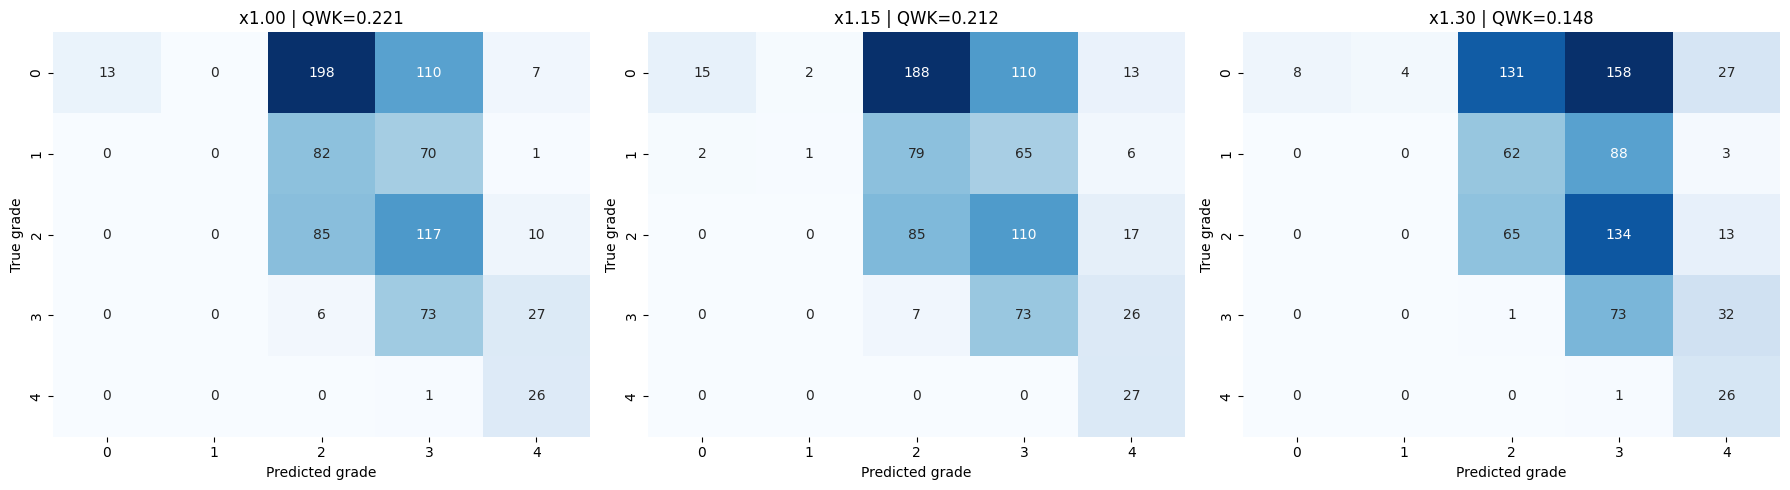

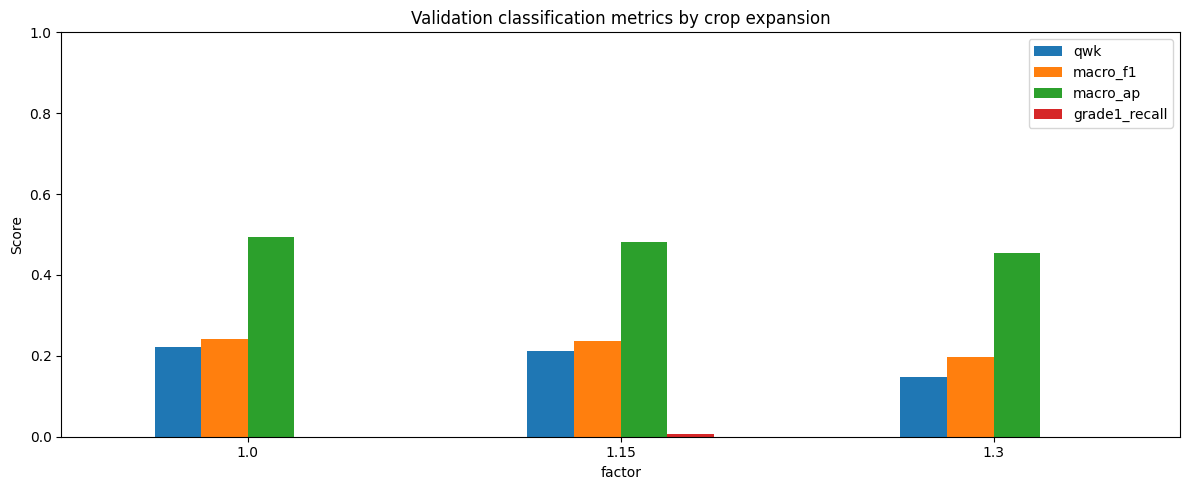

In [6]:
def evaluate_factor(factor):
    frame = manifest_df[manifest_df.factor == factor].sort_values(['patient_id', 'side']).reset_index(drop=True)
    loader = DataLoader(CropDataset(frame), batch_size=CLASSIFIER_BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    labels, predictions, probabilities = [], [], []
    with torch.inference_mode():
        for images, batch_labels, _ in tqdm(loader, desc=f'Classify x{factor:.2f}'):
            logits = model(images.to(DEVICE, non_blocking=True))
            probs = F.softmax(logits.float(), dim=1).cpu().numpy()
            labels.extend(batch_labels.numpy().tolist())
            probabilities.extend(probs.tolist())
            predictions.extend(probs.argmax(axis=1).tolist())
    labels = np.asarray(labels)
    predictions = np.asarray(predictions)
    probabilities = np.asarray(probabilities)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='macro', zero_division=0
    )
    one_hot = np.eye(5)[labels]
    metrics = {
        'factor': factor,
        'accuracy': float((labels == predictions).mean()),
        'qwk': float(cohen_kappa_score(labels, predictions, weights='quadratic')),
        'macro_precision': float(precision),
        'macro_recall': float(recall),
        'macro_f1': float(f1),
        'grade1_recall': float(recall_score(labels == 1, predictions == 1, zero_division=0)),
        'macro_ap': float(average_precision_score(one_hot, probabilities, average='macro')),
        'macro_auc': float(roc_auc_score(one_hot, probabilities, average='macro')),
        'mae': float(np.abs(labels - predictions).mean()),
    }
    metrics['selection_score'] = 0.55 * metrics['qwk'] + 0.30 * metrics['macro_f1'] + 0.15 * metrics['macro_ap']
    prediction_frame = frame.copy()
    prediction_frame['predicted_grade'] = predictions
    prediction_frame['confidence'] = probabilities.max(axis=1)
    prediction_frame['correct'] = labels == predictions
    prediction_frame.to_csv(LOCAL_RUN_DIR / f'predictions_x{factor:.2f}.csv', index=False)
    return metrics, labels, predictions, probabilities


classification_results = {}
for factor in EXPANSION_FACTORS:
    classification_results[factor] = evaluate_factor(factor)

classification_df = pd.DataFrame([classification_results[factor][0] for factor in EXPANSION_FACTORS])
classification_df.to_csv(LOCAL_RUN_DIR / 'classification_metrics.csv', index=False)
display(classification_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for axis, factor in zip(axes, EXPANSION_FACTORS):
    _, labels, predictions, _ = classification_results[factor]
    sns.heatmap(confusion_matrix(labels, predictions), annot=True, fmt='d', cmap='Blues', cbar=False, ax=axis)
    axis.set_title(f'x{factor:.2f} | QWK={classification_results[factor][0]["qwk"]:.3f}')
    axis.set_xlabel('Predicted grade')
    axis.set_ylabel('True grade')
plt.tight_layout()
confusion_path = LOCAL_RUN_DIR / 'confusion_matrices.png'
plt.savefig(confusion_path, dpi=180, bbox_inches='tight')
plt.show()

plot_metrics = ['qwk', 'macro_f1', 'macro_ap', 'grade1_recall']
classification_df.set_index('factor')[plot_metrics].plot(kind='bar', figsize=(12, 5), ylim=(0, 1))
plt.title('Validation classification metrics by crop expansion')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.tight_layout()
metric_plot_path = LOCAL_RUN_DIR / 'classification_metric_comparison.png'
plt.savefig(metric_plot_path, dpi=180, bbox_inches='tight')
plt.show()

## Stratified Grad-CAM audit

Up to 50 validation knees per grade are audited for every crop factor. Grad-CAM is computed for the predicted class. The anatomy masks are fixed proxies, not expert lesion annotations. Misclassified cases still receive both the prediction result and true grade in their saved comparison image.

Grad-CAM x1.00:   0%|          | 0/227 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/functional.py:154: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  img = torch.from_numpy(pic.transpose((2, 0, 1))).contiguous()


Grad-CAM x1.15:   0%|          | 0/227 [00:00<?, ?it/s]

Grad-CAM x1.30:   0%|          | 0/227 [00:00<?, ?it/s]

,factor,audited_cases,joint_energy,border_energy,lower_tibia_energy,peak_inside_rate,joint_occlusion_drop,audited_accuracy
0,1.00,227,0.699481,0.155613,0.130303,0.977974,0.419439,0.339207
1,1.15,227,0.788078,0.086614,0.097431,0.991189,0.417918,0.387665
2,1.30,227,0.801130,0.066131,0.101651,0.986784,0.448717,0.308370


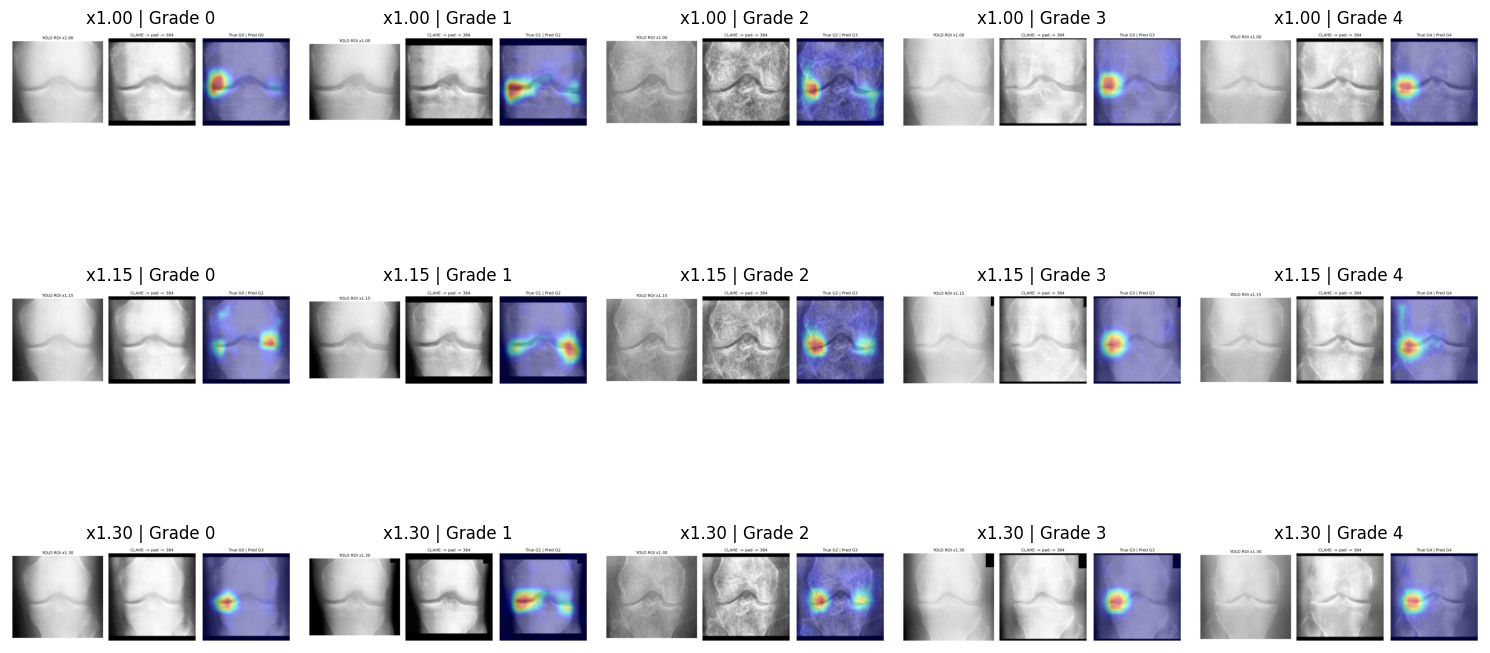

In [7]:
class DenseNetGradCAM:
    def __init__(self, model):
        self.model = model
        self.activations = None
        self.gradients = None
        self.handle = model.gradcam_target_layer.register_forward_hook(self._capture)

    def _capture(self, module, inputs, output):
        self.activations = output
        if output.requires_grad:
            output.register_hook(lambda gradient: setattr(self, 'gradients', gradient))

    def remove(self):
        self.handle.remove()

    def __call__(self, tensor, target_class=None):
        self.model.zero_grad(set_to_none=True)
        self.activations = None
        self.gradients = None
        for parameter in self.model.parameters():
            parameter.requires_grad_(True)
        with torch.enable_grad():
            logits = self.model(tensor)
            if target_class is None:
                target_class = int(logits.argmax(dim=1).item())
            logits[0, target_class].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=tensor.shape[-2:], mode='bilinear', align_corners=False)[0, 0]
        cam = cam.detach().float().cpu().numpy()
        maximum = float(cam.max())
        cam = cam / maximum if maximum > 1e-8 else np.zeros_like(cam)
        for parameter in self.model.parameters():
            parameter.requires_grad_(False)
        return logits.detach(), target_class, cam


def cam_metrics(cam):
    height, width = cam.shape
    joint = np.zeros_like(cam, dtype=bool)
    joint[int(.28*height):int(.72*height), int(.06*width):int(.94*width)] = True
    border = np.ones_like(cam, dtype=bool)
    border[int(.08*height):int(.92*height), int(.08*width):int(.92*width)] = False
    lower = np.zeros_like(cam, dtype=bool)
    lower[int(.72*height):, :] = True
    total = float(cam.sum()) + 1e-8
    peak_y, peak_x = np.unravel_index(np.argmax(cam), cam.shape)
    return {
        'joint_energy': float(cam[joint].sum() / total),
        'border_energy': float(cam[border].sum() / total),
        'lower_tibia_energy': float(cam[lower].sum() / total),
        'peak_inside_joint': int(joint[peak_y, peak_x]),
    }


def joint_occlusion_drop(tensor, predicted_grade):
    with torch.inference_mode():
        base = F.softmax(model(tensor), dim=1)[0, predicted_grade]
        occluded = tensor.clone()
        height, width = tensor.shape[-2:]
        occluded[:, :, int(.28*height):int(.72*height), int(.06*width):int(.94*width)] = 0
        after = F.softmax(model(occluded), dim=1)[0, predicted_grade]
    return float((base - after).item())


def overlay(processed_rgb, cam):
    heatmap = cv2.applyColorMap(np.uint8(np.clip(cam, 0, 1) * 255), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(processed_rgb, 0.60, heatmap, 0.40, 0)


def save_comparison(original, processed, cam, row, path):
    figure, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(original); axes[0].set_title(f'YOLO ROI x{row.factor:.2f}')
    axes[1].imshow(processed); axes[1].set_title('CLAHE -> pad -> 384')
    axes[2].imshow(overlay(processed, cam)); axes[2].set_title(f'True G{row.grade} | Pred G{row.predicted_grade}')
    for axis in axes: axis.axis('off')
    figure.tight_layout()
    figure.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(figure)


cam_engine = DenseNetGradCAM(model)
cam_rows = []
representative_paths = defaultdict(list)

for factor in EXPANSION_FACTORS:
    prediction_path = LOCAL_RUN_DIR / f'predictions_x{factor:.2f}.csv'
    frame = pd.read_csv(prediction_path)
    selected_parts = [group.sort_values(['patient_id', 'side']).head(CAM_CASES_PER_GRADE) for _, group in frame.groupby('grade')]
    selected = pd.concat(selected_parts, ignore_index=True)
    for row in tqdm(selected.itertuples(index=False), total=len(selected), desc=f'Grad-CAM x{factor:.2f}'):
        original, processed, image_tensor = prepare_image(row.crop_path)
        tensor = image_tensor.unsqueeze(0).to(DEVICE)
        logits, predicted_grade, cam = cam_engine(tensor)
        probabilities = F.softmax(logits.float(), dim=1)[0]
        metrics = cam_metrics(cam)
        audit_row = {
            'factor': factor,
            'patient_id': row.patient_id,
            'side': row.side,
            'true_grade': int(row.grade),
            'predicted_grade': int(predicted_grade),
            'correct': int(predicted_grade == int(row.grade)),
            'confidence': float(probabilities[predicted_grade].item()),
            **metrics,
            'joint_occlusion_drop': joint_occlusion_drop(tensor, predicted_grade),
        }
        cam_rows.append(audit_row)
        if len(representative_paths[(factor, int(row.grade))]) < 3:
            output_dir = LOCAL_RUN_DIR / 'gradcam_examples' / f'x{factor:.2f}'
            output_dir.mkdir(parents=True, exist_ok=True)
            output_path = output_dir / f'{row.patient_id}{row.side}_trueG{row.grade}_predG{predicted_grade}.jpg'
            save_comparison(original, processed, cam, row, output_path)
            representative_paths[(factor, int(row.grade))].append(output_path)

cam_engine.remove()
cam_df = pd.DataFrame(cam_rows)
cam_df.to_csv(LOCAL_RUN_DIR / 'gradcam_audit.csv', index=False)
cam_summary = cam_df.groupby('factor').agg(
    audited_cases=('patient_id', 'size'),
    joint_energy=('joint_energy', 'mean'),
    border_energy=('border_energy', 'mean'),
    lower_tibia_energy=('lower_tibia_energy', 'mean'),
    peak_inside_rate=('peak_inside_joint', 'mean'),
    joint_occlusion_drop=('joint_occlusion_drop', 'mean'),
    audited_accuracy=('correct', 'mean'),
).reset_index()
display(cam_summary)
cam_summary.to_csv(LOCAL_RUN_DIR / 'gradcam_summary.csv', index=False)

fig, axes = plt.subplots(len(EXPANSION_FACTORS), 5, figsize=(15, 3 * len(EXPANSION_FACTORS)))
for row_index, factor in enumerate(EXPANSION_FACTORS):
    for grade in GRADES:
        path = representative_paths[(factor, grade)][0]
        axes[row_index, grade].imshow(Image.open(path))
        axes[row_index, grade].set_title(f'x{factor:.2f} | Grade {grade}')
        axes[row_index, grade].axis('off')
plt.tight_layout()
montage_path = LOCAL_RUN_DIR / 'gradcam_expansion_montage.jpg'
plt.savefig(montage_path, dpi=160, bbox_inches='tight')
plt.show()

## Guardrailed decision and report

A candidate must remain within `0.01` of the raw crop for QWK, macro F1, and AP. Among eligible candidates, the notebook selects the strongest anatomy score (`joint energy - border energy + 0.1 * occlusion drop`). This prevents a visually attractive CAM from overriding a meaningful classification regression.

In [8]:
combined = classification_df.merge(cam_summary, on='factor', how='inner')
raw = combined.loc[np.isclose(combined.factor, 1.0)].iloc[0]
combined['classification_guardrail'] = (
    (combined.qwk >= raw.qwk - 0.01)
    & (combined.macro_f1 >= raw.macro_f1 - 0.01)
    & (combined.macro_ap >= raw.macro_ap - 0.01)
)
combined['anatomy_score'] = combined.joint_energy - combined.border_energy + 0.1 * combined.joint_occlusion_drop
eligible = combined[combined.classification_guardrail]
winner = eligible.sort_values(['anatomy_score', 'selection_score'], ascending=False).iloc[0]
recommended_factor = float(winner.factor)
combined.to_csv(LOCAL_RUN_DIR / 'combined_results.csv', index=False)
display(combined)

config = {
    'run_timestamp_utc': RUN_TIMESTAMP,
    'purpose': 'validation-only production-YOLO crop expansion selection',
    'test_split_accessed': False,
    'dataset': 'Mendeley KneeXrayData v1 / OAI',
    'source_h5_resolution': '256x320 bilateral RGB',
    'expansion_factors': list(EXPANSION_FACTORS),
    'yolo_checkpoint': str(YOLO_CHECKPOINT),
    'yolo_sha256': yolo_sha256,
    'densenet_checkpoint': str(DENSENET_CHECKPOINT),
    'densenet_sha256': densenet_sha256,
    'preprocessing': 'LAB CLAHE 1.25 -> square pad -> resize 384 -> ImageNet normalization',
    'cam_method': 'Grad-CAM at timm DenseNet121 features.norm5',
    'recommended_factor': recommended_factor,
    'decision_rule': 'classification guardrails, then anatomy score',
    'limitation': 'low-resolution detector HDF5; no bounding-box ground truth or GT IoU',
}
(LOCAL_RUN_DIR / 'run_config.json').write_text(json.dumps(config, indent=2), encoding='utf-8')

report_lines = [
    '# DenseNet-121 Production-YOLO Crop Expansion Ablation', '',
    f'- Run: `{RUN_NAME}`',
    '- Split: validation only; test was not accessed',
    f'- YOLO SHA-256: `{yolo_sha256}`',
    f'- DenseNet SHA-256: `{densenet_sha256}`',
    f'- Recommended expansion: **x{recommended_factor:.2f}**', '',
    '## Classification Metrics', '',
    combined[['factor','accuracy','qwk','macro_f1','grade1_recall','macro_ap','macro_auc','mae','selection_score']].to_markdown(index=False), '',
    '## Grad-CAM Proxy Metrics', '',
    combined[['factor','audited_cases','joint_energy','border_energy','lower_tibia_energy','peak_inside_rate','joint_occlusion_drop','classification_guardrail','anatomy_score']].to_markdown(index=False), '',
    '## Interpretation', '',
    'The selected factor satisfies the classification guardrails and has the strongest anatomy proxy score among eligible arms.',
    'These masks are broad geometry proxies, not expert JSN or osteophyte annotations.',
    'The source HDF5 images are only 256x320 bilateral images; this experiment selects crop geometry and does not prove full-resolution production performance.',
]
(LOCAL_RUN_DIR / 'REPORT.md').write_text('\n'.join(report_lines), encoding='utf-8')

DRIVE_RUN_DIR.parent.mkdir(parents=True, exist_ok=True)
shutil.copytree(LOCAL_RUN_DIR, DRIVE_RUN_DIR, dirs_exist_ok=True)
archive_path = shutil.make_archive(str(LOCAL_RUN_DIR), 'zip', LOCAL_RUN_DIR)
shutil.copy2(archive_path, DRIVE_RUN_DIR.parent / Path(archive_path).name)

print(f'Recommended expansion: x{recommended_factor:.2f}')
print('Report:', DRIVE_RUN_DIR / 'REPORT.md')
print('All artifacts:', DRIVE_RUN_DIR)
print('Next: inspect the montage and report before changing production crop policy or training.')

,factor,accuracy,qwk,macro_precision,macro_recall,macro_f1,grade1_recall,macro_ap,macro_auc,mae,selection_score,audited_cases,joint_energy,border_energy,lower_tibia_energy,peak_inside_rate,joint_occlusion_drop,audited_accuracy,classification_guardrail,anatomy_score
0,1.00,0.238499,0.220636,0.358415,0.418444,0.240907,0.000000,0.494204,0.731133,1.392252,0.267752,227,0.699481,0.155613,0.130303,0.977974,0.419439,0.339207,True,0.585812
1,1.15,0.243341,0.212473,0.391947,0.428378,0.235535,0.006536,0.482689,0.731402,1.411622,0.259924,227,0.788078,0.086614,0.097431,0.991189,0.417918,0.387665,False,0.743256
2,1.30,0.208232,0.148199,0.333837,0.396527,0.198118,0.000000,0.453601,0.709788,1.560533,0.208985,227,0.801130,0.066131,0.101651,0.986784,0.448717,0.308370,False,0.779871


Recommended expansion: x1.00
Report: /content/drive/MyDrive/Models/densenet121_crop_expansion_ablations/2026-07-29_04-54-34_954198_UTC_yolo_crop_expansion_ablation/REPORT.md
All artifacts: /content/drive/MyDrive/Models/densenet121_crop_expansion_ablations/2026-07-29_04-54-34_954198_UTC_yolo_crop_expansion_ablation
Next: inspect the montage and report before changing production crop policy or training.


In [9]:
try:
    from google.colab import runtime
    print('Experiment complete. Releasing the Colab runtime...')
    runtime.unassign()
except ImportError:
    print('Not running in Colab; runtime release skipped.')

Experiment complete. Releasing the Colab runtime...
